# Visualizing Learned Age-Conditioned Temporal Decay

This notebook loads a trained age-conditioned TALE-EHR checkpoint and visualizes the learned temporal weighting function $w(\Delta t, a)$ across age and elapsed time. All figures are generated from model parameters and synthetic age/time sweeps (no patient-level EHR sequences are used).


In [1]:
#CHECKPOINT_PATH = "checkpoints/age_real_full0504_2130/epoch_010.pt"
CHECKPOINT_PATH = "checkpoints/age_real_202605112156/epoch_003.pt"
EMBEDDING_PATH = "data/processed/bge_embeddings.pt"
VOCAB_PATH = "data/processed/code_vocab.json"
DEVICE = "cpu"  # CPU is fine for this analysis, no large data

DEFAULTS = {
    "d_model": 256,
    "poly_degree": 5,
    "age_conditioning_mode": "real",
    "age_emb_dim": 32,
    "age_hidden_dim": 64,
    "demo_hidden": 64,
}

ckpt_path = REPO_ROOT / CHECKPOINT_PATH
embedding_path = REPO_ROOT / EMBEDDING_PATH
vocab_path = REPO_ROOT / VOCAB_PATH
ckpt_dir = ckpt_path.parent
config_path = ckpt_dir / "config.json"

if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
if not embedding_path.exists():
    raise FileNotFoundError(f"Embedding file not found: {embedding_path}")
if not vocab_path.exists():
    raise FileNotFoundError(f"Vocab file not found: {vocab_path}")

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)
num_codes = len(vocab)

cfg = {}
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)
else:
    print(f"WARNING: config.json not found at {config_path}; using defaults.")

ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = ckpt["model_state_dict"]

resolved = DEFAULTS.copy()
resolved["d_model"] = int(cfg.get("d_model", resolved["d_model"]))
resolved["poly_degree"] = int(cfg.get("poly_degree", resolved["poly_degree"]))
resolved["age_conditioning_mode"] = str(
    cfg.get("age_conditioning_mode", ckpt.get("age_conditioning_mode", resolved["age_conditioning_mode"]))
)

missing_from_config = [k for k in ["d_model", "poly_degree"] if k not in cfg]
if missing_from_config:
    print(
        "WARNING: config.json missing "
        f"{missing_from_config}; falling back to defaults { {k: DEFAULTS[k] for k in missing_from_config} }."
    )

model = TALEEHRAge(
    embedding_path=embedding_path,
    num_codes=num_codes,
    d_model=resolved["d_model"],
    poly_degree=resolved["poly_degree"],
    demo_hidden=resolved["demo_hidden"],
    age_conditioning_mode=resolved["age_conditioning_mode"],
    age_emb_dim=resolved["age_emb_dim"],
    age_hidden_dim=resolved["age_hidden_dim"],
)

model.load_state_dict(state_dict)
model = model.to(DEVICE).double()
model.eval()

coeff = model.time_aware_attention.temporal_weight.coefficients.detach()
last_w = model.time_aware_attention.temporal_weight.age_coeff_gen.mlp[-1].weight.detach()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Loaded checkpoint sanity info")
print("- checkpoint:", ckpt_path)
print("- epoch:", ckpt.get("epoch", "unknown"))
print("- model_variant:", ckpt.get("model_variant", cfg.get("model_variant", "unknown")))
print("- age_conditioning_mode:", resolved["age_conditioning_mode"])
print("- d_model:", resolved["d_model"], "poly_degree:", resolved["poly_degree"])
print("- num_codes:", num_codes)
print("- total params:", total_params)
print("- trainable params:", trainable_params)
print("- learned base polynomial coefficients:", [round(float(x), 6) for x in coeff.cpu()])
print("- age-MLP last-layer weight L2 norm:", float(last_w.norm().cpu()))

NameError: name 'REPO_ROOT' is not defined

In [9]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from IPython.display import Markdown, display

# Resolve repo root from this notebook location and make model imports work.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from model.tale_ehr import TALEEHR
from model.tale_ehr_age import TALEEHRAge
from model.age_embedding import FourierAgeEmbedding

# Publication-style plotting defaults.
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
AGE_PALETTE = sns.color_palette("viridis", n_colors=6)

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Will be set by Cell 2 — used by later cells to skip age-specific plots
# when the loaded model is the baseline.
IS_AGE_CONDITIONED = None

print(f"Repo root: {REPO_ROOT}")
print(f"Figures dir: {FIGURES_DIR}")
print(f"Torch version: {torch.__version__}")

Repo root: /home/suraj/Git/Age-conditioned-pediatric-EHR
Figures dir: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures
Torch version: 2.8.0+rocm6.4


In [10]:
# Switch CHECKPOINT_PATH between baseline and age-conditioned runs.
# Comment / uncomment one of these:
#CHECKPOINT_PATH = "checkpoints/age_real_202605112156/epoch_003.pt"  # baseline TALE-EHR
#CHECKPOINT_PATH = "checkpoints/age_real_full0504_2130/epoch_010.pt"   # age-conditioned (TTE or something)
CHECKPOINT_PATH = "/home/suraj/Git/Age-conditioned-pediatric-EHR/checkpoints/age_real_202605112156/epoch_012.pt"   # age-conditioned (Weibull- Best so far)

EMBEDDING_PATH = "data/processed/bge_embeddings.pt"
VOCAB_PATH = "data/processed/code_vocab.json"
DEVICE = "cpu"

DEFAULTS = {
    "d_model": 256,
    "poly_degree": 5,
    "demo_hidden": 64,
    "age_conditioning_mode": "real",
    "age_emb_dim": 32,
    "age_hidden_dim": 64,
}

ckpt_path = REPO_ROOT / CHECKPOINT_PATH
embedding_path = REPO_ROOT / EMBEDDING_PATH
vocab_path = REPO_ROOT / VOCAB_PATH
ckpt_dir = ckpt_path.parent
config_path = ckpt_dir / "config.json"

for required, label in [(ckpt_path, "Checkpoint"), (embedding_path, "Embedding"), (vocab_path, "Vocab")]:
    if not required.exists():
        raise FileNotFoundError(f"{label} not found: {required}")

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)
num_codes = len(vocab)

# Load checkpoint metadata first so we can detect variant.
ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = ckpt["model_state_dict"]

cfg = {}
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)
else:
    print(f"WARNING: config.json not found at {config_path}; using defaults.")

# --- Detect model variant ---
# Priority: explicit checkpoint key > config.json key > infer from state_dict keys.
def detect_variant(state_dict, ckpt_meta, cfg_meta):
    explicit = ckpt_meta.get("model_variant") or cfg_meta.get("model_variant")
    if explicit in ("baseline", "age_conditioned"):
        return explicit
    # Fall back to inspection: age-conditioned models have an `age_coeff_gen` submodule.
    has_age_module = any("age_coeff_gen" in k or "age_emb" in k for k in state_dict.keys())
    return "age_conditioned" if has_age_module else "baseline"

model_variant = detect_variant(state_dict, ckpt, cfg)

# Resolve architectural args.
resolved = DEFAULTS.copy()
resolved["d_model"] = int(cfg.get("d_model", resolved["d_model"]))
resolved["poly_degree"] = int(cfg.get("poly_degree", resolved["poly_degree"]))
resolved["age_conditioning_mode"] = str(
    cfg.get("age_conditioning_mode",
            ckpt.get("age_conditioning_mode", resolved["age_conditioning_mode"]))
)

missing_from_config = [k for k in ["d_model", "poly_degree"] if k not in cfg]
if missing_from_config:
    print(f"WARNING: config.json missing {missing_from_config}; "
          f"using defaults {{k: DEFAULTS[k] for k in missing_from_config}}.")

# --- Instantiate the right class ---
if model_variant == "age_conditioned":
    model = TALEEHRAge(
        embedding_path=embedding_path,
        num_codes=num_codes,
        d_model=resolved["d_model"],
        poly_degree=resolved["poly_degree"],
        demo_hidden=resolved["demo_hidden"],
        age_conditioning_mode=resolved["age_conditioning_mode"],
        age_emb_dim=resolved["age_emb_dim"],
        age_hidden_dim=resolved["age_hidden_dim"],
    )
elif model_variant == "baseline":
    model = TALEEHR(
        embedding_path=embedding_path,
        num_codes=num_codes,
        d_model=resolved["d_model"],
        poly_degree=resolved["poly_degree"],
        demo_hidden=resolved["demo_hidden"],
    )
else:
    raise ValueError(f"Unknown model_variant: {model_variant!r}")

model.load_state_dict(state_dict)
model = model.to(DEVICE).double()
model.eval()

IS_AGE_CONDITIONED = (model_variant == "age_conditioned")

# --- Print sanity info ---
coeff = model.time_aware_attention.temporal_weight.coefficients.detach()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Loaded checkpoint sanity info")
print(f"- checkpoint:        {ckpt_path}")
print(f"- epoch:             {ckpt.get('epoch', 'unknown')}")
print(f"- detected variant:  {model_variant}")
print(f"- d_model:           {resolved['d_model']}, poly_degree: {resolved['poly_degree']}")
print(f"- num_codes:         {num_codes}")
print(f"- total params:      {total_params:,}")
print(f"- trainable params:  {trainable_params:,}")
print(f"- learned base poly: {[round(float(x), 6) for x in coeff.cpu()]}")

if IS_AGE_CONDITIONED:
    last_w = model.time_aware_attention.temporal_weight.age_coeff_gen.mlp[-1].weight.detach()
    print(f"- age conditioning mode: {resolved['age_conditioning_mode']}")
    print(f"- age-MLP last-layer weight L2 norm: {float(last_w.norm().cpu()):.6f}")
else:
    print("- age conditioning: NOT PRESENT (baseline TALE-EHR)")

Loaded checkpoint sanity info
- checkpoint:        /home/suraj/Git/Age-conditioned-pediatric-EHR/checkpoints/age_real_202605112156/epoch_012.pt
- epoch:             12
- detected variant:  age_conditioned
- d_model:           256, poly_degree: 5
- num_codes:         30635
- total params:      11,058,117
- trainable params:  11,058,117
- learned base poly: [0.69229, -0.327038, -0.026285, 0.060683, 0.027433, -0.070096]
- age conditioning mode: real
- age-MLP last-layer weight L2 norm: 1.896985


In [11]:
def _require_age_conditioned(model):
    if not hasattr(model.time_aware_attention, "age_emb"):
        raise RuntimeError(
            "This helper requires an age-conditioned model. "
            "The currently loaded model is the baseline TALE-EHR."
        )

def get_age_features(model, ages_years):
    """Run the Fourier embedding on a 1D tensor of ages in years.
    Returns shape [N, 32]."""
    ages = torch.as_tensor(ages_years, dtype=torch.float64, device=next(model.parameters()).device)
    if ages.ndim != 1:
        raise ValueError(f"ages_years must be 1D, got shape {tuple(ages.shape)}")
    with torch.no_grad():
        feats = model.time_aware_attention.age_emb(ages)
    return feats


def get_delta_alpha(model, ages_years):
    """Compute Delta_alpha for each age. Returns shape [N, 6] for poly_degree=5."""
    age_features = get_age_features(model, ages_years)
    with torch.no_grad():
        delta_alpha = model.time_aware_attention.temporal_weight.age_coeff_gen(age_features)
    return delta_alpha


def get_full_alpha(model, ages_years):
    """Compute alpha_k(a) = base_k + Delta_alpha_k(a). Returns shape [N, 6]."""
    delta_alpha = get_delta_alpha(model, ages_years)
    base = model.time_aware_attention.temporal_weight.coefficients.view(1, -1)
    return base + delta_alpha


def compute_w_curve(model, ages_years, delta_t_grid):
    """For each (age, delta_t) pair, compute the temporal weight w.
    ages_years: [N_ages] in years.
    delta_t_grid: [N_dt] in log1p(weeks) units (matching how the model was trained).
    Returns shape [N_ages, N_dt]."""
    ages = torch.as_tensor(ages_years, dtype=torch.float64, device=next(model.parameters()).device)
    dt = torch.as_tensor(delta_t_grid, dtype=torch.float64, device=next(model.parameters()).device)
    if ages.ndim != 1:
        raise ValueError(f"ages_years must be 1D, got shape {tuple(ages.shape)}")
    if dt.ndim != 1:
        raise ValueError(f"delta_t_grid must be 1D, got shape {tuple(dt.shape)}")

    age_features = get_age_features(model, ages).unsqueeze(1)  # [N_ages, 1, 32]
    dt_tensor = dt.view(1, 1, -1).expand(ages.shape[0], 1, dt.shape[0])  # [N_ages, 1, N_dt]

    with torch.no_grad():
        w = model.time_aware_attention.temporal_weight(dt_tensor, age_features)
    return w.squeeze(1)


print("Helper functions ready.")

Helper functions ready.


## Figure 1 — Learned base polynomial vs zero-init

This shows the temporal decay learned by the age-MLP independent of age (the baseline polynomial that all ages share), compared to the zero-initialization (which is what TALE-EHR's polynomial would be after no training).


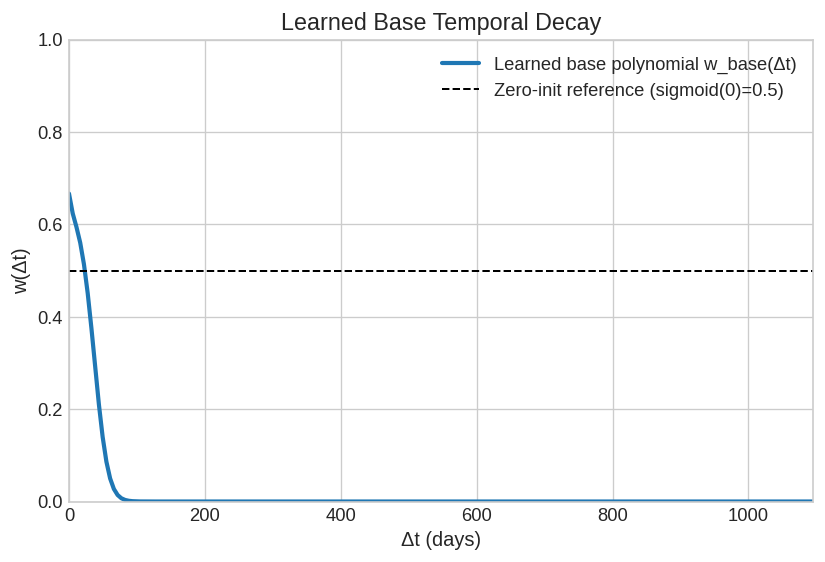

Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/base_polynomial_decay.png
Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/base_polynomial_decay.pdf


In [12]:
days_grid = np.linspace(0.0, 1095.0, 200)
log_dt_grid = np.log1p(days_grid / 7.0)

coeff = model.time_aware_attention.temporal_weight.coefficients.detach().cpu().numpy().astype(np.float64)
poly = np.zeros_like(log_dt_grid)
for k, c in enumerate(coeff):
    poly += c * (log_dt_grid ** k)
w_base = 1.0 / (1.0 + np.exp(-poly))

fig, ax = plt.subplots()
ax.plot(days_grid, w_base, lw=2.5, label="Learned base polynomial w_base(Δt)")
ax.axhline(0.5, color="black", linestyle="--", lw=1.2, label="Zero-init reference (sigmoid(0)=0.5)")
ax.set_xlim(0, 1095)
ax.set_ylim(0, 1)
ax.set_xlabel("Δt (days)")
ax.set_ylabel("w(Δt)")
ax.set_title("Learned Base Temporal Decay")
ax.legend(loc="best")

png_path = FIGURES_DIR / "base_polynomial_decay.png"
pdf_path = FIGURES_DIR / "base_polynomial_decay.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

## Figure 2 — Age-conditioned temporal decay curves (headline figure)

This is the central result: the learned temporal weight as a function of (a) elapsed time and (b) patient age. Each curve is a different age. If all curves overlap, age conditioning did nothing. If curves diverge systematically, the model learned age-specific decay shapes.


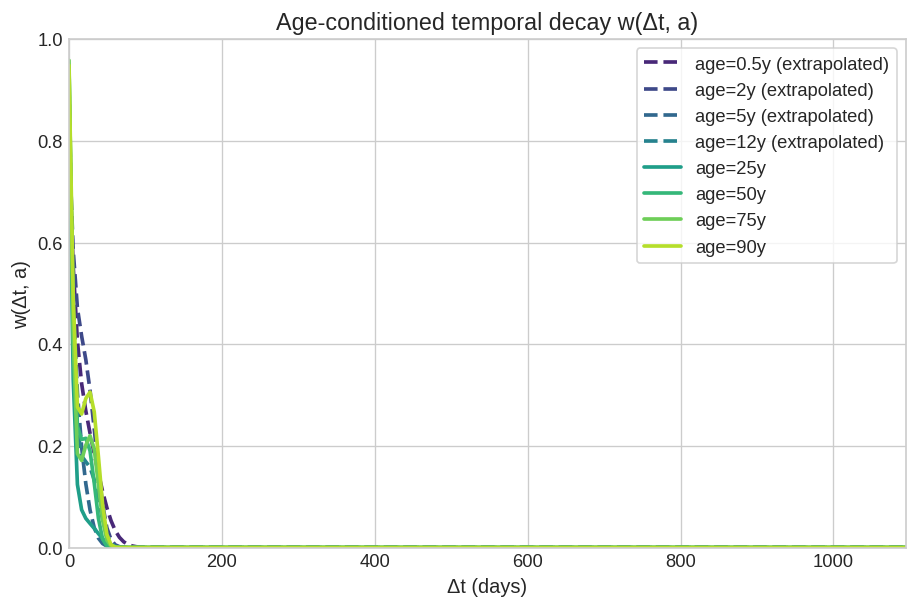

Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/age_decay_curves.png
Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/age_decay_curves.pdf


In [13]:
ages_to_plot = np.array([0.5, 2, 5, 12, 25, 50, 75, 90], dtype=np.float64)
days_grid = np.linspace(0.0, 1095.0, 200)
log_dt_grid = np.log1p(days_grid / 7.0)

w_curves = compute_w_curve(model, ages_to_plot, log_dt_grid).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(9, 5.5))
curve_colors = sns.color_palette("viridis", n_colors=len(ages_to_plot))
for age, curve, color in zip(ages_to_plot, w_curves, curve_colors):
    is_extrap = age < 18.0
    label = f"age={age:g}y" + (" (extrapolated)" if is_extrap else "")
    ls = "--" if is_extrap else "-"
    ax.plot(days_grid, curve, color=color, lw=2.2, linestyle=ls, label=label)

ax.set_xlim(0, 1095)
ax.set_ylim(0, 1)
ax.set_xlabel("Δt (days)")
ax.set_ylabel("w(Δt, a)")
ax.set_title("Age-conditioned temporal decay w(Δt, a)")
ax.legend(loc="upper right", frameon=True)

png_path = FIGURES_DIR / "age_decay_curves.png"
pdf_path = FIGURES_DIR / "age_decay_curves.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

Adult age curves should be inspected for systematic separation (e.g., older adults showing stronger attenuation at longer lags). Pediatric ages here are extrapolations because training used adult MIMIC-IV; sensible behavior means smooth bounded continuation from late adolescence rather than unstable divergence.


## Figure 3 — Magnitude of age-conditioning across age

This shows the magnitude of age-conditioning for each age. Larger values mean the model is reshaping the polynomial more aggressively for that age.


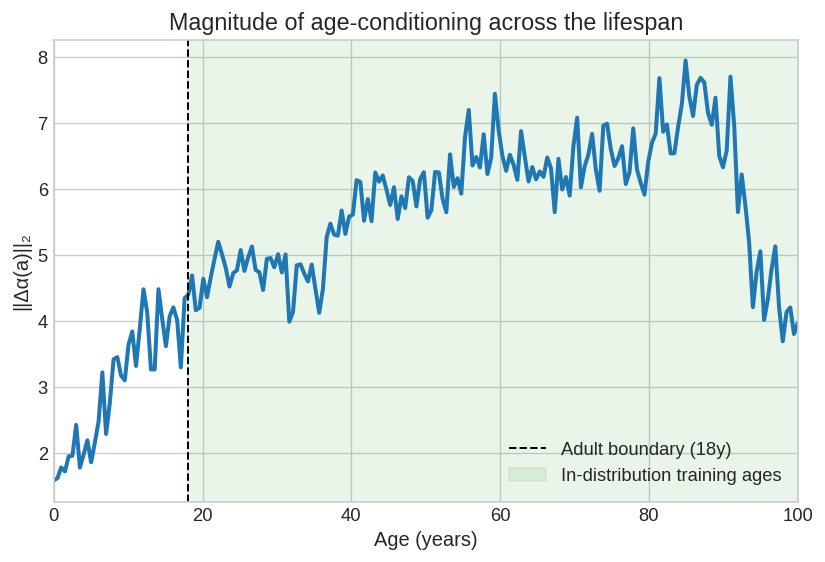

Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/delta_alpha_magnitude.png


In [14]:
age_grid = np.linspace(0.0, 100.0, 200)
delta_alpha = get_delta_alpha(model, age_grid).detach().cpu().numpy()
delta_norm = np.linalg.norm(delta_alpha, axis=1)

fig, ax = plt.subplots()
ax.plot(age_grid, delta_norm, lw=2.4, color="tab:blue")
ax.axvline(18.0, color="black", linestyle="--", lw=1.2, label="Adult boundary (18y)")
ax.axvspan(18.0, 100.0, color="tab:green", alpha=0.10, label="In-distribution training ages")
ax.set_xlim(0, 100)
ax.set_xlabel("Age (years)")
ax.set_ylabel("||Δα(a)||₂")
ax.set_title("Magnitude of age-conditioning across the lifespan")
ax.legend(loc="best")

png_path = FIGURES_DIR / "delta_alpha_magnitude.png"
#pdf_path = FIGURES_DIR / "delta_alpha_magnitude.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
#fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved: {png_path}")
#print(f"Saved: {pdf_path}")

Compare this curve to training diagnostics: if older adults show larger norms than young adults, the notebook agrees with the observed trend. In pediatric extrapolation, a bounded smooth norm profile suggests controlled extrapolation; rapid growth near age 0 indicates potential runaway behavior.


## Figure 4 — Per-coefficient age-conditioning breakdown

Decomposes age-conditioning into each polynomial coefficient. If only $Δα_0$ changes, age mainly shifts decay up/down; movement in higher-order terms indicates true age-dependent decay shape changes.


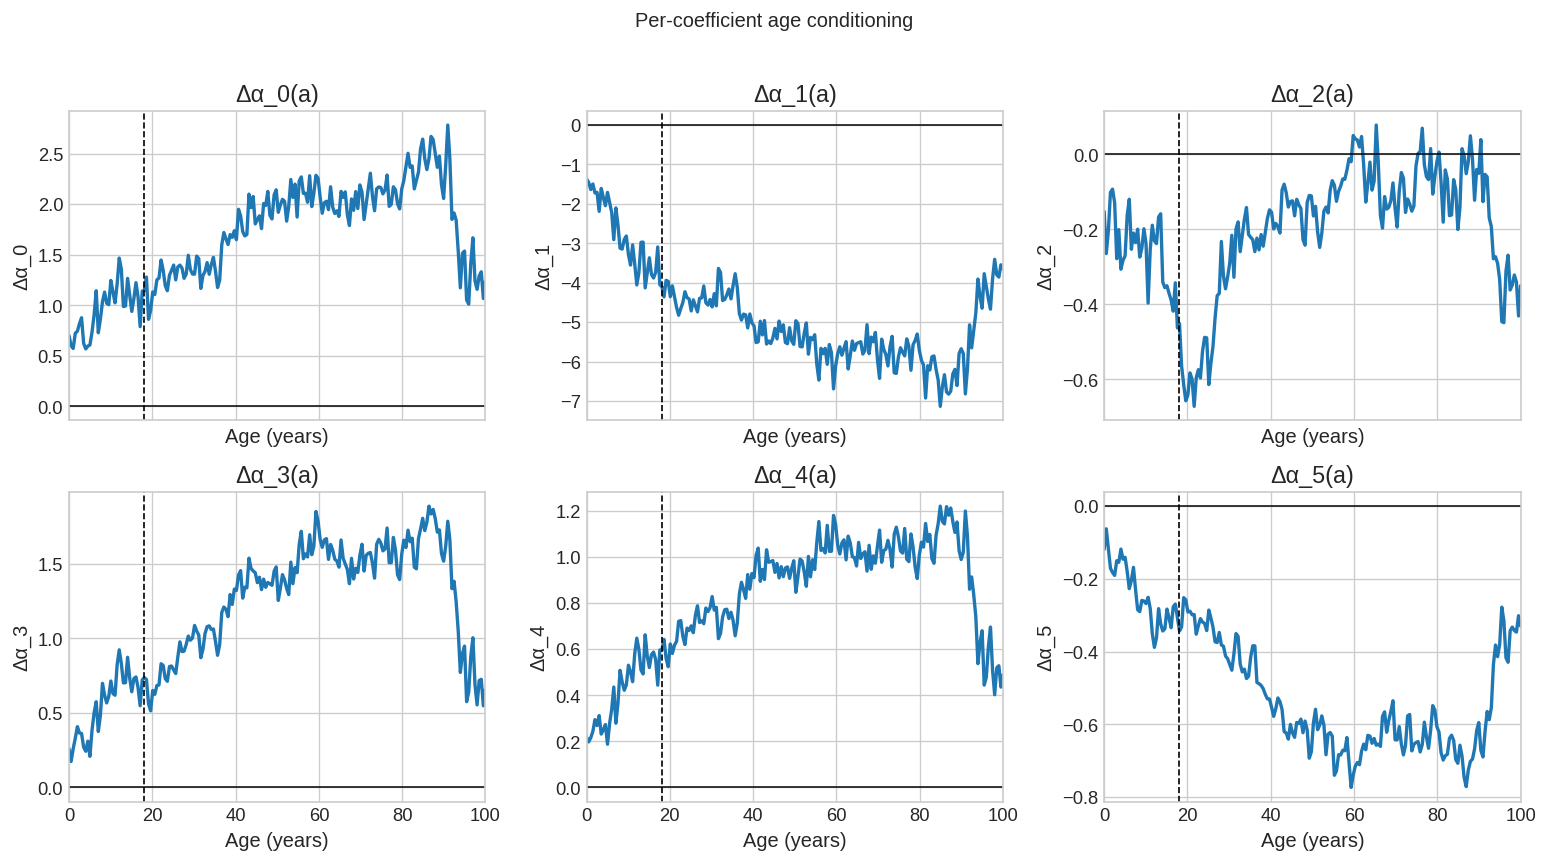

Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/per_coefficient_breakdown.png


In [15]:
age_grid = np.linspace(0.0, 100.0, 200)
delta_alpha = get_delta_alpha(model, age_grid).detach().cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for k, ax in enumerate(axes.flatten()):
    ax.plot(age_grid, delta_alpha[:, k], lw=2.0)
    ax.axhline(0.0, color="black", linestyle="-", lw=0.9)
    ax.axvline(18.0, color="black", linestyle="--", lw=1.0)
    ax.set_title(f"Δα_{k}(a)")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel(f"Δα_{k}")

fig.suptitle("Per-coefficient age conditioning", y=1.02)
fig.tight_layout()

png_path = FIGURES_DIR / "per_coefficient_breakdown.png"
#pdf_path = FIGURES_DIR / "per_coefficient_breakdown.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
#fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved: {png_path}")
#print(f"Saved: {pdf_path}")

Inspect which coefficients have the largest dynamic range over age. Strong variation in $k\ge2$ coefficients implies age changes the curvature and higher-order shape of temporal decay, not just a global offset.


## Figure 5 — Heatmap of the full decay surface

Heatmap version of Figure 2: all ages on one axis, all elapsed times on the other, with color encoding $w(\Delta t, a)$. This reveals continuous structure beyond discrete sampled age curves.


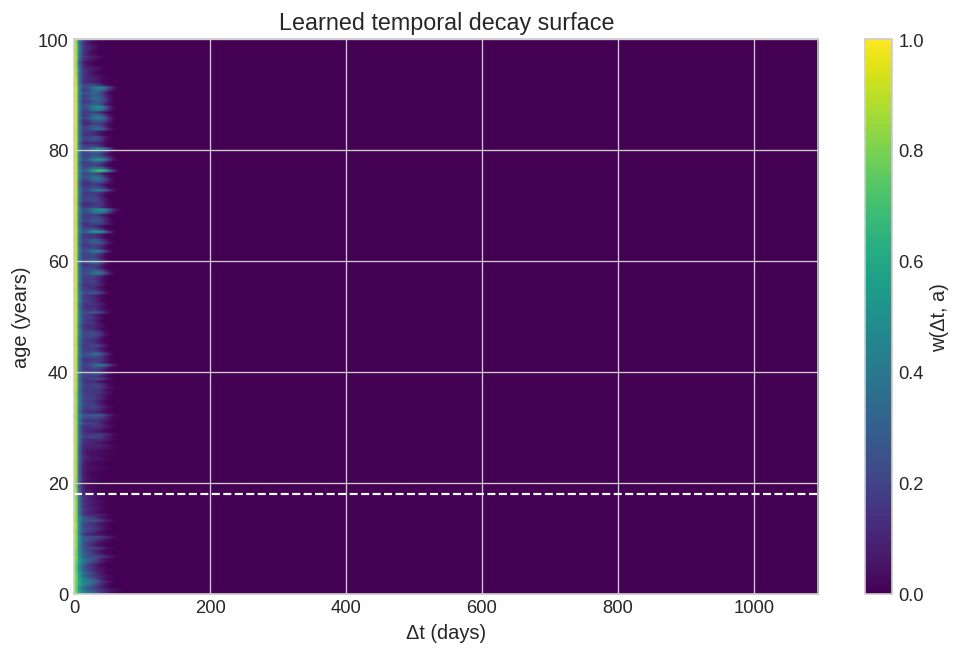

Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/decay_heatmap.png


In [16]:
age_grid = np.linspace(0.0, 100.0, 200)
days_grid = np.linspace(0.0, 1095.0, 200)
log_dt_grid = np.log1p(days_grid / 7.0)

w_surface = compute_w_curve(model, age_grid, log_dt_grid).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    w_surface,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    extent=[days_grid.min(), days_grid.max(), age_grid.min(), age_grid.max()],
    vmin=0.0,
    vmax=1.0,
)
ax.axhline(18.0, color="white", linestyle="--", lw=1.3)
ax.set_xlabel("Δt (days)")
ax.set_ylabel("age (years)")
ax.set_title("Learned temporal decay surface")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("w(Δt, a)")

png_path = FIGURES_DIR / "decay_heatmap.png"
#pdf_path = FIGURES_DIR / "decay_heatmap.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
#fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved: {png_path}")
#print(f"Saved: {pdf_path}")

## Figure 6 — Effective coefficient comparison at anchor ages

Compares effective coefficients $\alpha_k(a)=\alpha_k^{base}+Δ\alpha_k(a)$ at neonatal, adolescent, young adult, middle-age, and older-adult anchors, with the base polynomial as reference.


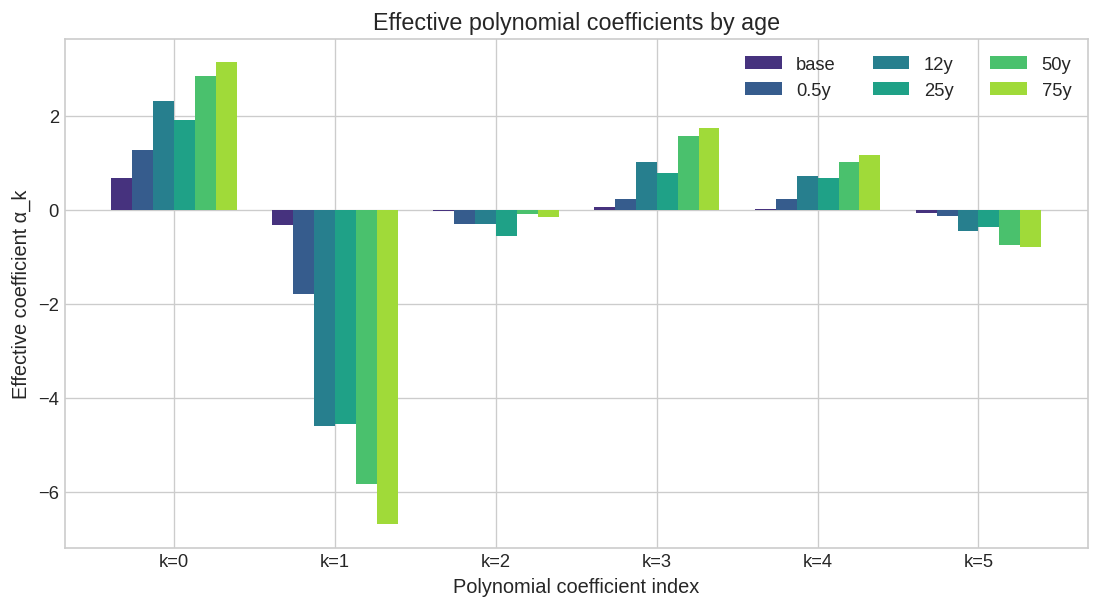

Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/effective_coefficients.png


In [17]:
anchor_ages = np.array([0.5, 12, 25, 50, 75], dtype=np.float64)
full_alpha = get_full_alpha(model, anchor_ages).detach().cpu().numpy()
base_alpha = model.time_aware_attention.temporal_weight.coefficients.detach().cpu().numpy()[None, :]

labels = ["base", "0.5y", "12y", "25y", "50y", "75y"]
all_alpha = np.vstack([base_alpha, full_alpha])
K = all_alpha.shape[1]

x = np.arange(K)
bar_width = 0.13
colors = sns.color_palette("viridis", n_colors=len(labels))

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, (label, color) in enumerate(zip(labels, colors)):
    ax.bar(x + i * bar_width, all_alpha[i], width=bar_width, label=label, color=color)

ax.set_xticks(x + bar_width * (len(labels) - 1) / 2)
ax.set_xticklabels([f"k={k}" for k in range(K)])
ax.set_xlabel("Polynomial coefficient index")
ax.set_ylabel("Effective coefficient α_k")
ax.set_title("Effective polynomial coefficients by age")
ax.legend(loc="best", ncol=3)

png_path = FIGURES_DIR / "effective_coefficients.png"
#pdf_path = FIGURES_DIR / "effective_coefficients.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
#fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved: {png_path}")
#print(f"Saved: {pdf_path}")

## Quantitative summary

Numerical summary of what the model learned for concise paper text.


In [18]:
canonical_ages = np.array([0.5, 5, 12, 25, 50, 75, 90], dtype=np.float64)
canon_delta = get_delta_alpha(model, canonical_ages).detach().cpu().numpy()
canon_norms = np.linalg.norm(canon_delta, axis=1)

age_grid = np.linspace(0.0, 100.0, 200)
delta_grid = get_delta_alpha(model, age_grid).detach().cpu().numpy()

base_coeff = model.time_aware_attention.temporal_weight.coefficients.detach().cpu().numpy().astype(np.float64)
per_k_min = delta_grid.min(axis=0)
per_k_max = delta_grid.max(axis=0)

delta_norm_grid = np.linalg.norm(delta_grid, axis=1)
max_idx = int(np.argmax(delta_norm_grid))
max_age = float(age_grid[max_idx])
max_norm = float(delta_norm_grid[max_idx])

age_model_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
baseline_model = TALEEHR(
    embedding_path=embedding_path,
    num_codes=num_codes,
    d_model=resolved["d_model"],
    poly_degree=resolved["poly_degree"],
    demo_hidden=resolved["demo_hidden"],
).to(DEVICE)
baseline_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
added_params = age_model_params - baseline_params

rows = []
rows.append("| Metric | Value |")
rows.append("|---|---:|")
rows.append(f"| Base polynomial coefficients | `{[round(float(x), 6) for x in base_coeff]}` |")
for a, nrm in zip(canonical_ages, canon_norms):
    rows.append(f"| ||Δα||₂ at age {a:g} | {float(nrm):.6f} |")
for k, (mn, mx) in enumerate(zip(per_k_min, per_k_max)):
    rows.append(f"| Δα_{k}(a) range over [0,100] | [{float(mn):.6f}, {float(mx):.6f}] |")
rows.append(f"| Added trainable params vs baseline | {added_params} |")
rows.append(f"| Baseline trainable params | {baseline_params} |")
rows.append(f"| Age-conditioned trainable params | {age_model_params} |")
rows.append(f"| Age where ||Δα(a)||₂ is maximal | {max_age:.2f} years |")
rows.append(f"| Max ||Δα(a)||₂ | {max_norm:.6f} |")

display(Markdown("\n".join(rows)))
print("Quantitative summary rendered as markdown table.")

| Metric | Value |
|---|---:|
| Base polynomial coefficients | `[0.69229, -0.327038, -0.026285, 0.060683, 0.027433, -0.070096]` |
| ||Δα||₂ at age 0.5 | 1.618418 |
| ||Δα||₂ at age 5 | 1.987732 |
| ||Δα||₂ at age 12 | 4.734528 |
| ||Δα||₂ at age 25 | 4.540153 |
| ||Δα||₂ at age 50 | 6.234611 |
| ||Δα||₂ at age 75 | 7.157652 |
| ||Δα||₂ at age 90 | 6.074209 |
| Δα_0(a) range over [0,100] | [0.567945, 2.781707] |
| Δα_1(a) range over [0,100] | [-7.134959, -1.366127] |
| Δα_2(a) range over [0,100] | [-0.671729, 0.078190] |
| Δα_3(a) range over [0,100] | [0.173828, 1.885251] |
| Δα_4(a) range over [0,100] | [0.187384, 1.220614] |
| Δα_5(a) range over [0,100] | [-0.773419, -0.062301] |
| Added trainable params vs baseline | 5004 |
| Baseline trainable params | 11053113 |
| Age-conditioned trainable params | 11058117 |
| Age where ||Δα(a)||₂ is maximal | 84.92 years |
| Max ||Δα(a)||₂ | 7.948267 |

Quantitative summary rendered as markdown table.


## Diagnostic — was age conditioning actually used?

This falsification check compares age-MLP weight norms to their zero-init baseline. If the final layer remains near zero, age-conditioning was effectively inert.


In [19]:
last_w = model.time_aware_attention.temporal_weight.age_coeff_gen.mlp[-1].weight.detach()
last_b = model.time_aware_attention.temporal_weight.age_coeff_gen.mlp[-1].bias.detach()
first_w = model.time_aware_attention.temporal_weight.age_coeff_gen.mlp[0].weight.detach()

last_w_norm = float(last_w.norm().cpu())
last_b_norm = float(last_b.norm().cpu())
first_w_norm = float(first_w.norm().cpu())

print("Age MLP diagnostic norms")
print(f"- ||last layer weight||_2: {last_w_norm:.6f}")
print(f"- ||last layer bias||_2:   {last_b_norm:.6f}")
print(f"- ||first layer weight||_2:{first_w_norm:.6f}")

if last_w_norm < 1e-3:
    print("WARNING: last-layer weight norm < 1e-3 (possible inert age-conditioning).")
else:
    print("PASS: last-layer weight norm is non-trivial; conditioning module was used.")

Age MLP diagnostic norms
- ||last layer weight||_2: 1.896985
- ||last layer bias||_2:   0.392382
- ||first layer weight||_2:6.009097
PASS: last-layer weight norm is non-trivial; conditioning module was used.


## Comparison hook (for later)

When the `random_constant` run is ready, change `CHECKPOINT_PATH` at the top of this notebook and re-run all cells. You should observe age-insensitive curves where $w(\Delta t, a)$ overlaps across ages because the conditioning module ignores age input in that mode. This serves as a falsification anchor.
